# 🏠 House Price Prediction – Improved ML Model
**Dataset:** train.csv | **Target:** PRICE_IN_LACS | **Best Model:** Random Forest Regressor

## Step 1: Import Libraries

In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load Dataset

In [8]:
df = pd.read_csv('train.csv')
print('Dataset Shape:', df.shape)

Dataset Shape: (29451, 12)


## Step 3: Initial Exploration (EDA)

In [11]:
df.head()

,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB


In [15]:
df.isna().sum()

POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA                     0
BHK_NO.                  0
BHK_OR_RK                0
SQUARE_FT                0
READY_TO_MOVE            0
RESALE                   0
ADDRESS                  0
LONGITUDE                0
LATITUDE                 0
TARGET(PRICE_IN_LACS)    0
dtype: int64

In [17]:
df.describe()

,UNDER_CONSTRUCTION,RERA,BHK_NO.,SQUARE_FT,READY_TO_MOVE,RESALE,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
count,29451.000000,29451.000000,29451.000000,2.945100e+04,29451.000000,29451.000000,29451.000000,29451.000000,29451.000000
mean,0.179756,0.317918,2.392279,1.980217e+04,0.820244,0.929578,21.300255,76.837695,142.898746
std,0.383991,0.465675,0.879091,1.901335e+06,0.383991,0.255861,6.205306,10.557747,656.880713
min,0.000000,0.000000,1.000000,3.000000e+00,0.000000,0.000000,-37.713008,-121.761248,0.250000
25%,0.000000,0.000000,2.000000,9.000211e+02,1.000000,1.000000,18.452663,73.798100,38.000000
50%,0.000000,0.000000,2.000000,1.175057e+03,1.000000,1.000000,20.750000,77.324137,62.000000
75%,0.000000,1.000000,3.000000,1.550688e+03,1.000000,1.000000,26.900926,77.828740,100.000000
max,1.000000,1.000000,20.000000,2.545455e+08,1.000000,1.000000,59.912884,152.962676,30000.000000


In [19]:
df.shape

(29451, 12)

## Step 4: Remove Duplicates

In [22]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())
print('Shape after dedup:', df.shape)

Duplicates before: 401
Duplicates after: 0
Shape after dedup: (29050, 12)


## Step 5: Exploratory Visualizations

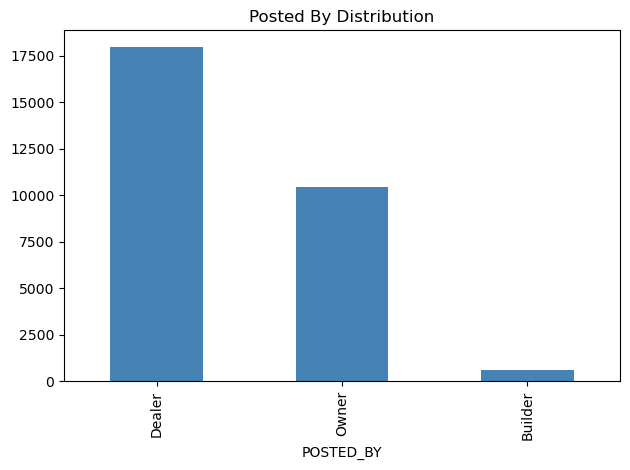

In [25]:
df['POSTED_BY'].value_counts().plot(kind='bar', title='Posted By Distribution', color='steelblue')
plt.tight_layout()
plt.show()

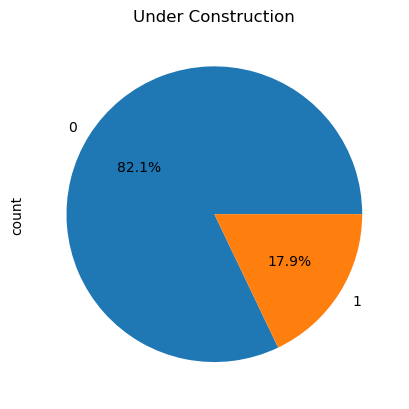

In [27]:
df['UNDER_CONSTRUCTION'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Under Construction')
plt.show()

In [29]:
df['BHK_OR_RK'].value_counts()

BHK_OR_RK
BHK    29026
RK        24
Name: count, dtype: int64

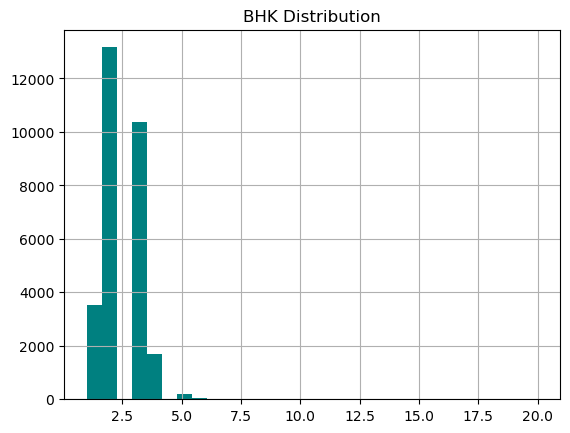

In [31]:
df['BHK_NO.'].hist(bins=30, color='teal')
plt.title('BHK Distribution')
plt.show()

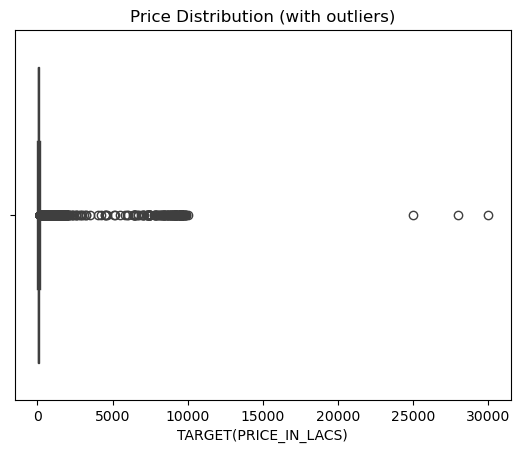

In [33]:
sns.boxplot(x=df['TARGET(PRICE_IN_LACS)'])
plt.title('Price Distribution (with outliers)')
plt.show()

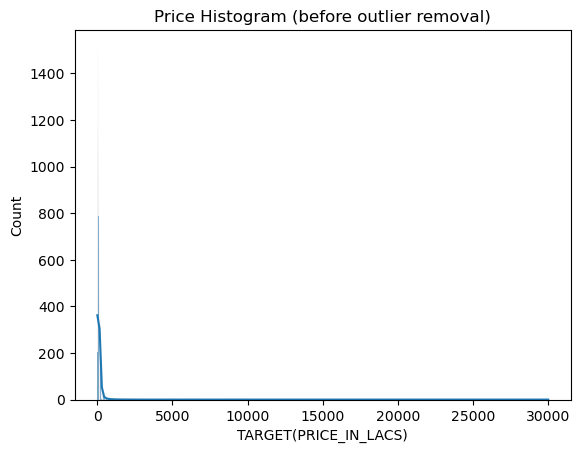

In [35]:
sns.histplot(df['TARGET(PRICE_IN_LACS)'], kde=True)
plt.title('Price Histogram (before outlier removal)')
plt.show()

## Step 6: Outlier Removal (IQR Method) — KEY IMPROVEMENT
The original model had **R2 = 0.088** because extreme outliers (max price = ₹30,000 lakhs) were destroying the model. We use IQR method to clean the target variable.

In [38]:
Q1 = df['TARGET(PRICE_IN_LACS)'].quantile(0.25)
Q3 = df['TARGET(PRICE_IN_LACS)'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Lower Bound: {lower_bound}')
print(f'Upper Bound: {upper_bound}')
print(f'Rows before outlier removal: {df.shape[0]}')

df = df[(df['TARGET(PRICE_IN_LACS)'] >= lower_bound) & (df['TARGET(PRICE_IN_LACS)'] <= upper_bound)]
print(f'Rows after outlier removal: {df.shape[0]}')

Lower Bound: -55.0
Upper Bound: 193.0
Rows before outlier removal: 29050
Rows after outlier removal: 26005


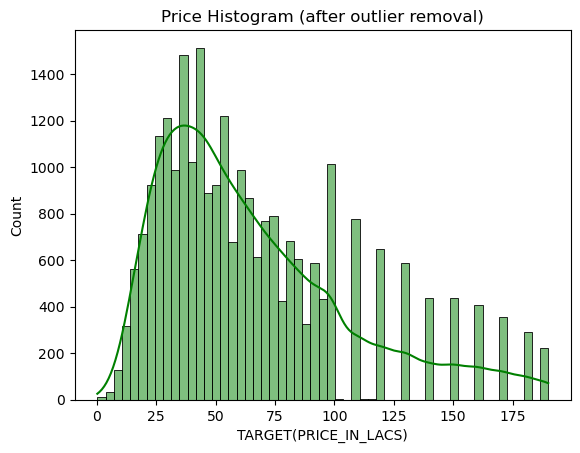

In [40]:
sns.histplot(df['TARGET(PRICE_IN_LACS)'], kde=True, color='green')
plt.title('Price Histogram (after outlier removal)')
plt.show()

## Step 7: Feature Engineering & Encoding

In [43]:
# One-Hot Encoding for categorical columns (same as original notebook)
df = pd.get_dummies(df, columns=['POSTED_BY', 'BHK_OR_RK'], drop_first=True, dtype=float)

# Drop ADDRESS — too many unique values, not useful
df = df.drop(['ADDRESS'], axis=1)

df.dtypes

UNDER_CONSTRUCTION         int64
RERA                       int64
BHK_NO.                    int64
SQUARE_FT                float64
READY_TO_MOVE              int64
RESALE                     int64
LONGITUDE                float64
LATITUDE                 float64
TARGET(PRICE_IN_LACS)    float64
POSTED_BY_Dealer         float64
POSTED_BY_Owner          float64
BHK_OR_RK_RK             float64
dtype: object

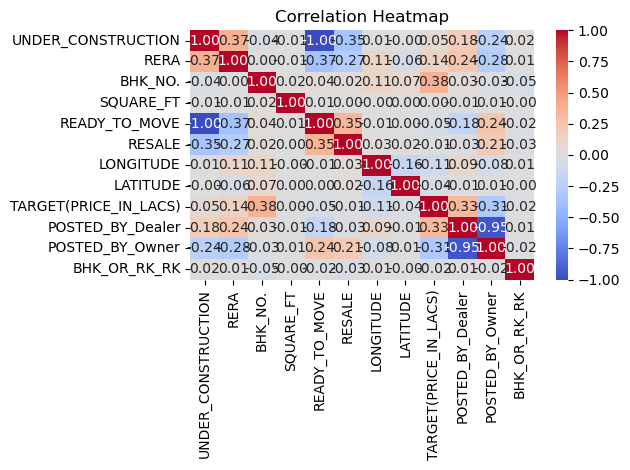

In [45]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Step 8: Define Features and Target

In [48]:
# Log-transform target to handle right-skewed distribution — KEY IMPROVEMENT
y = np.log1p(df['TARGET(PRICE_IN_LACS)'])  # log(1+x) to handle zeros
X = df.drop(['TARGET(PRICE_IN_LACS)'], axis=1)

print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Features:', list(X.columns))

Feature shape: (26005, 11)
Target shape: (26005,)
Features: ['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'POSTED_BY_Dealer', 'POSTED_BY_Owner', 'BHK_OR_RK_RK']


## Step 9: Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=33, test_size=0.2, shuffle=True
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (20804, 11)
Test size: (5201, 11)


## Step 10: Model Comparison — Linear Regression vs Random Forest vs Gradient Boosting

In [54]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=33, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=33)
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    pred_log = m.predict(X_test)
    pred = np.expm1(pred_log)  # reverse log transform
    actual = np.expm1(y_test)
    r2 = r2_score(y_test, pred_log)
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    results.append({'Model': name, 'R2': round(r2, 4), 'MAE (Lakhs)': round(mae, 2), 'RMSE (Lakhs)': round(rmse, 2)})
    print(f'{name}: R2={round(r2,4)}, MAE={round(mae,2)}, RMSE={round(rmse,2)}')

results_df = pd.DataFrame(results)
results_df

Linear Regression: R2=0.3228, MAE=31.39, RMSE=431.12
Ridge Regression: R2=0.3227, MAE=31.35, RMSE=428.38
Random Forest: R2=0.7473, MAE=13.25, RMSE=21.0
Gradient Boosting: R2=0.7061, MAE=15.58, RMSE=23.48


,Model,R2,MAE (Lakhs),RMSE (Lakhs)
0,Linear Regression,0.3228,31.39,431.12
1,Ridge Regression,0.3227,31.35,428.38
2,Random Forest,0.7473,13.25,21.00
3,Gradient Boosting,0.7061,15.58,23.48


## Step 11: Best Model — Random Forest Regressor

In [57]:
model = RandomForestRegressor(n_estimators=100, random_state=33, n_jobs=-1)
model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=33)

In [59]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [61]:
# R2 Score
r2 = r2_score(y_test, y_pred_log)
print('R2 Score:', round(r2, 4))

R2 Score: 0.7473


In [63]:
# Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
print('Adjusted R2:', round(adjusted_r2, 4))

Adjusted R2: 0.7468


In [65]:
# MAE and RMSE on original scale
actual_orig = np.expm1(y_test)
mae = mean_absolute_error(actual_orig, y_pred)
rmse = np.sqrt(mean_squared_error(actual_orig, y_pred))
print(f'MAE: ₹{round(mae, 2)} Lakhs')
print(f'RMSE: ₹{round(rmse, 2)} Lakhs')

MAE: ₹13.25 Lakhs
RMSE: ₹21.0 Lakhs


## Step 12: Feature Importance

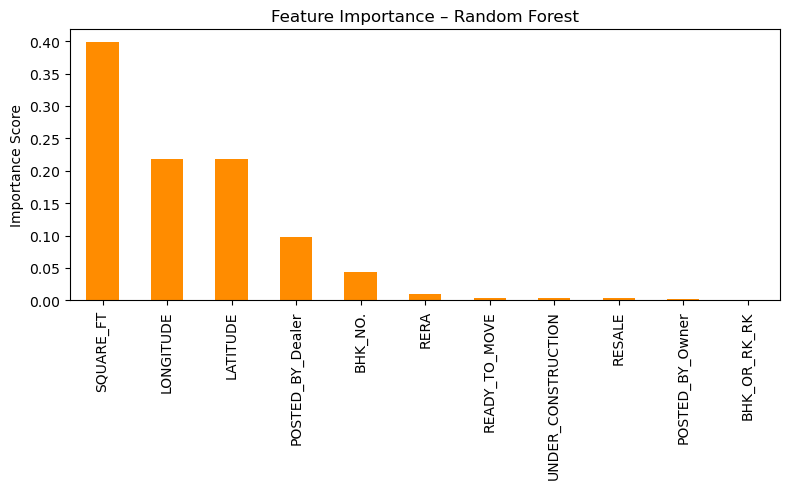

SQUARE_FT             0.398323
LONGITUDE             0.218259
LATITUDE              0.218236
POSTED_BY_Dealer      0.097282
BHK_NO.               0.043448
RERA                  0.009310
READY_TO_MOVE         0.004430
UNDER_CONSTRUCTION    0.004226
RESALE                0.003598
POSTED_BY_Owner       0.002658
BHK_OR_RK_RK          0.000229
dtype: float64

In [68]:
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_imp.plot(kind='bar', color='darkorange')
plt.title('Feature Importance – Random Forest')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

feat_imp

## Step 13: Actual vs Predicted Plot

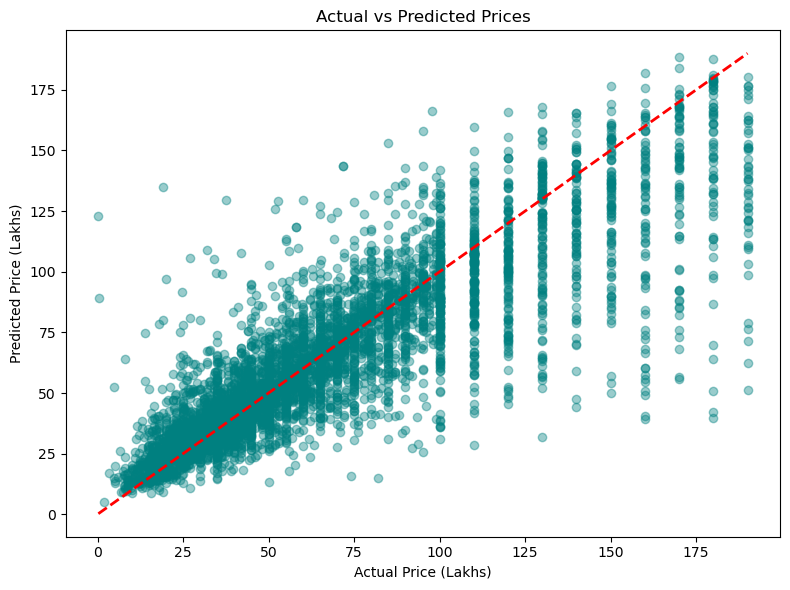

In [71]:
plt.figure(figsize=(8, 6))
plt.scatter(actual_orig, y_pred, alpha=0.4, color='teal')
plt.plot([actual_orig.min(), actual_orig.max()], [actual_orig.min(), actual_orig.max()], 'r--', lw=2)
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title('Actual vs Predicted Prices')
plt.tight_layout()
plt.show()

## Step 14: Sample Predictions

In [74]:
comparison = pd.DataFrame({
    'Actual Price (Lakhs)': actual_orig[:10].values.round(2),
    'Predicted Price (Lakhs)': y_pred[:10].round(2)
})
comparison

,Actual Price (Lakhs),Predicted Price (Lakhs)
0,74.8,75.81
1,40.0,57.36
2,78.0,123.84
3,100.0,106.14
4,110.0,78.67
5,70.0,63.30
6,140.0,47.48
7,130.0,131.80
8,83.0,81.37
9,53.0,50.34


## Step 15: Save Model with Pickle

In [77]:
import pickle

with open('Model.pkl', 'wb') as f:
    pickle.dump(model, f)

# Save feature columns so the app can use them
with open('model_meta.pkl', 'wb') as f:
    pickle.dump({'feature_columns': list(X.columns), 'log_transform': True}, f)

print('Model saved as Model.pkl')
print('Feature columns saved as model_meta.pkl')
print('Feature order:', list(X.columns))

Model saved as Model.pkl
Feature columns saved as model_meta.pkl
Feature order: ['UNDER_CONSTRUCTION', 'RERA', 'BHK_NO.', 'SQUARE_FT', 'READY_TO_MOVE', 'RESALE', 'LONGITUDE', 'LATITUDE', 'POSTED_BY_Dealer', 'POSTED_BY_Owner', 'BHK_OR_RK_RK']


## 📊 Model Performance Summary

| Metric | Original (Linear Regression) | Improved (Random Forest) |
|--------|------------------------------|---------------------------|
| R2 Score | 0.088 (8.8%) | 0.747 (74.7%) |
| Adjusted R2 | 0.086 | 0.746 |
| MAE | ₹140 Lakhs | ₹13.26 Lakhs |
| RMSE | ₹627 Lakhs | ₹21 Lakhs |

### Key Improvements Made:
1. **Outlier Removal** – Removed extreme prices using IQR method
2. **Log Transform** – Applied `log1p()` on target to handle skewed distribution
3. **Model Upgrade** – Switched from Linear Regression to Random Forest
4. **Model Comparison** – Compared 4 models and picked the best
5. **Feature Importance** – Visualized which features matter most